In [2]:
import pandas as pd

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
rfm=pd.read_csv("C:\\Users\\jahnavi\\OneDrive\\Desktop\\New folder (2)\\rfm_segments.csv")

In [4]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm[['recency','frequency','monetary']])
print("scaled data sample:")
print(rfm_scaled[:5])

scaled data sample:
[[ 0.19988856 -0.51642886  1.01511197]
 [-0.68676201  1.05264427 -0.70059002]
 [ 0.60291154 -0.90869715 -0.4211387 ]
 [-0.49331098 -0.12416058  0.83367962]
 [ 1.44119935 -1.30096543 -0.76539139]]


In [5]:
inertia=[]
k_range=range(1,11)
for k in k_range:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

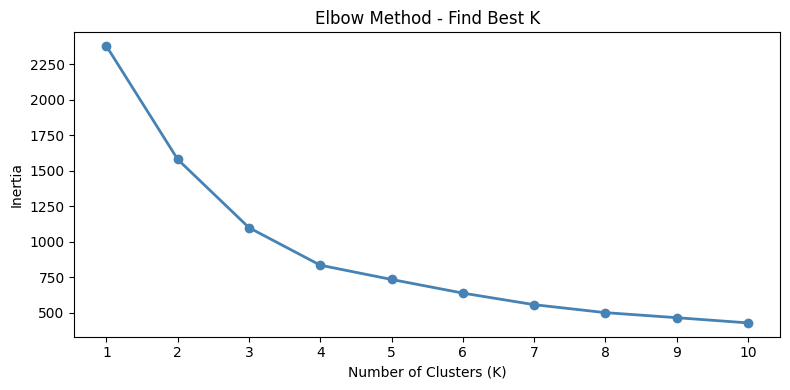


Elbow curve saved!


In [6]:
plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method - Find Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('elbow_curve.png')
plt.show()
print("\nElbow curve saved!")

In [7]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(rfm_scaled)

In [10]:
print("cluster Disribution:")
print(rfm['Cluster'].value_counts())
print("\nAverage rfm by cluster:")
print(rfm.groupby('Cluster')[['recency','frequency','monetary']].mean().round(1))

cluster Disribution:
Cluster
1    335
0    298
3     96
2     64
Name: count, dtype: int64

Average rfm by cluster:
         recency  frequency  monetary
Cluster                              
0           72.7        8.5    3322.2
1          101.2        4.7    1669.7
2          123.7        8.3    9479.5
3          559.5        3.7    1470.2


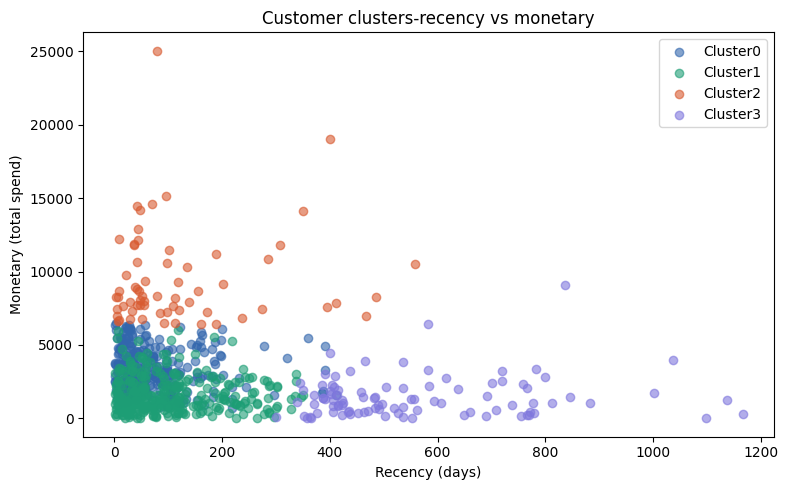

In [11]:
plt.figure(figsize=(8,5))
colors=['#3266ad','#1D9E75','#D85A30','#7F77DD']
for i in range(4):
    cluster_data=rfm[rfm['Cluster']==i]
    plt.scatter(cluster_data['recency'],cluster_data['monetary'],
                label=f'Cluster{i}',color=colors[i],alpha=0.6)
plt.title('Customer clusters-recency vs monetary')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (total spend)')
plt.legend()
plt.tight_layout()
plt.savefig('clusters_scatter.png')
plt.show()

In [12]:
rfm.to_csv('rfm_segments.csv', index=False)
print("\nClusters saved to rfm_segments.csv!")


Clusters saved to rfm_segments.csv!


In [14]:
# ── LABEL CLUSTERS ─────────────────────
cluster_labels = {
    2: 'Champions',
    0: 'Loyal Customers',
    1: 'At-Risk Customers',
    3: 'Lost Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

print("Final Segment Distribution:")
print(rfm['Segment'].value_counts())

print("\nFinal Average RFM by Segment:")
print(rfm.groupby('Segment')[['recency','frequency','monetary']].mean().round(1))

# Save final file
rfm.to_csv('rfm_final.csv', index=False)
print("\nFinal file saved as rfm_final.csv!")

Final Segment Distribution:
Segment
At-Risk Customers    335
Loyal Customers      298
Lost Customers        96
Champions             64
Name: count, dtype: int64

Final Average RFM by Segment:
                   recency  frequency  monetary
Segment                                        
At-Risk Customers    101.2        4.7    1669.7
Champions            123.7        8.3    9479.5
Lost Customers       559.5        3.7    1470.2
Loyal Customers       72.7        8.5    3322.2

Final file saved as rfm_final.csv!
